# 06 — Fairness & Disparate Impact Analysis

**Objective**: Evaluate whether the recommended financial model produces
systematically different approval rates across demographic cohorts.

**Why this matters**: Credit scoring models in production must comply with
fair-lending regulations (ECOA in the US, LGPD + BACEN Resolution 4.557
in Brazil). Even when protected attributes are not used as features,
proxy effects (e.g. age correlating with income) can create disparate impact.

**Method**:
1. Score the validation set with the calibrated financial model
2. Group by age cohorts and income cohorts
3. Compute approval rate per group at the recommended threshold (0.15)
4. Apply the **4/5ths rule**: if the lowest group's approval rate is less
   than 80% of the highest group's rate, that signals potential disparate impact

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.split import load_splits
from src.api.model_store import DEFAULT_THRESHOLD, FINANCIAL_FEATURES

plt.rcParams["figure.dpi"] = 100

splits = load_splits(PROJECT_ROOT / "data" / "processed")
val = splits["val"]

model = joblib.load(PROJECT_ROOT / "models" / "xgboost_financial.pkl")
calibrator = joblib.load(PROJECT_ROOT / "models" / "xgboost_financial_calibrator.pkl")

X_val = val[FINANCIAL_FEATURES].astype("float64")
y_val = val["target"].values

raw_proba = model.predict_proba(X_val)[:, 1]
cal_proba = calibrator.transform(raw_proba)

val_scored = val.copy()
val_scored["prob_default"] = cal_proba
val_scored["approved"] = (cal_proba < DEFAULT_THRESHOLD).astype(int)

print(f"Validation set: {len(val_scored):,} rows")
print(f"Overall approval rate: {val_scored['approved'].mean():.2%}")
print(f"Threshold: {DEFAULT_THRESHOLD}")

Validation set: 22,500 rows
Overall approval rate: 86.62%
Threshold: 0.15


## Age Cohort Analysis

Age is not a protected class in credit (unlike race or gender), but
age-based disparities can raise regulatory scrutiny. Younger borrowers
typically have shorter credit histories, which may translate to higher
predicted default rates.

In [2]:
age_bins = [18, 30, 40, 50, 60, 70, 120]
age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
val_scored["age_group"] = pd.cut(val_scored["age"], bins=age_bins, labels=age_labels, right=False)

age_stats = val_scored.groupby("age_group", observed=True).agg(
    n=("approved", "count"),
    approval_rate=("approved", "mean"),
    avg_prob_default=("prob_default", "mean"),
    actual_default_rate=("target", "mean"),
).round(4)

print("Approval rates by age group:")
age_stats

Approval rates by age group:


,n,approval_rate,avg_prob_default,actual_default_rate
age_group,,,,
18-29,1347,0.7305,0.1202,0.1166
30-39,3371,0.7870,0.1011,0.1047
40-49,5124,0.8279,0.0844,0.0785
50-59,5390,0.8685,0.0664,0.0699
60-69,4276,0.9404,0.0357,0.0370
70+,2992,0.9723,0.0194,0.0191


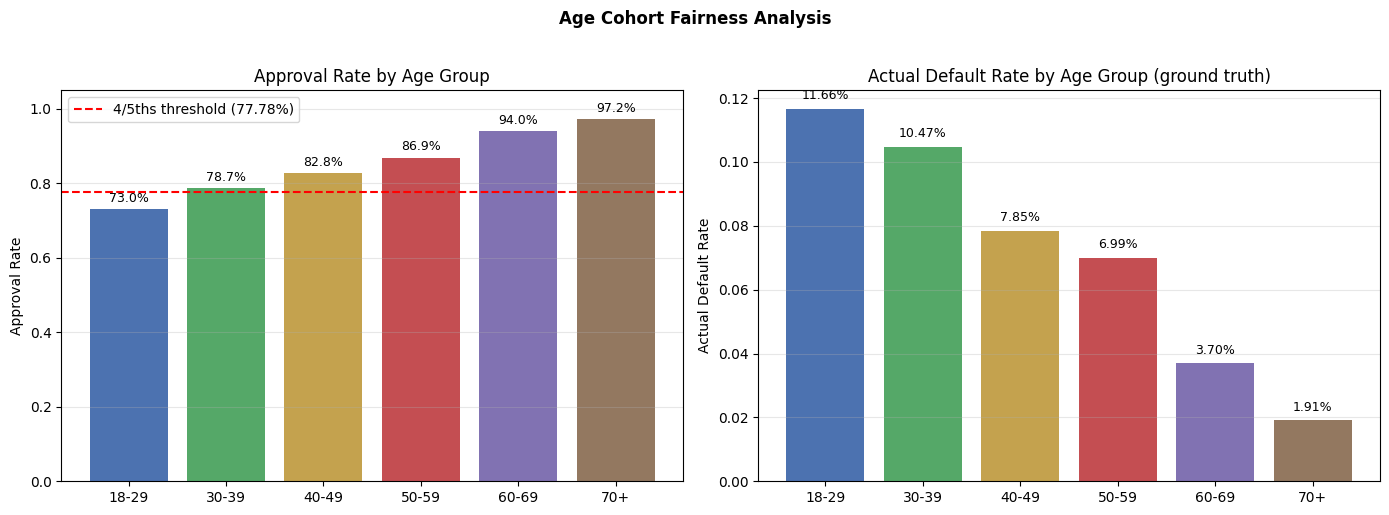

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#4C72B0", "#55A868", "#C4A24E", "#C44E52", "#8172B2", "#937860"]

# Approval rate
axes[0].bar(age_stats.index, age_stats["approval_rate"], color=colors[:len(age_stats)])
axes[0].axhline(y=0.8 * age_stats["approval_rate"].max(), color="red", ls="--",
               label=f"4/5ths threshold ({0.8 * age_stats['approval_rate'].max():.2%})")
axes[0].set_ylabel("Approval Rate")
axes[0].set_title("Approval Rate by Age Group")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(age_stats["approval_rate"]):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)

# Actual default rate for context
axes[1].bar(age_stats.index, age_stats["actual_default_rate"], color=colors[:len(age_stats)])
axes[1].set_ylabel("Actual Default Rate")
axes[1].set_title("Actual Default Rate by Age Group (ground truth)")
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(age_stats["actual_default_rate"]):
    axes[1].text(i, v + 0.003, f"{v:.2%}", ha="center", fontsize=9)

fig.suptitle("Age Cohort Fairness Analysis", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [4]:
# 4/5ths rule check for age
max_rate = age_stats["approval_rate"].max()
min_rate = age_stats["approval_rate"].min()
ratio = min_rate / max_rate if max_rate > 0 else 0

print(f"Highest approval rate: {max_rate:.2%} ({age_stats['approval_rate'].idxmax()})")
print(f"Lowest approval rate:  {min_rate:.2%} ({age_stats['approval_rate'].idxmin()})")
print(f"Ratio (lowest/highest): {ratio:.4f}")
print(f"4/5ths rule threshold: 0.8000")
print()
if ratio >= 0.80:
    print("PASS: No evidence of disparate impact by age.")
else:
    print("FLAG: Potential disparate impact by age — ratio below 80%.")
    print("This does not necessarily mean the model is unfair — younger borrowers")
    print("may genuinely have higher default rates. But it warrants further investigation.")

Highest approval rate: 97.23% (70+)
Lowest approval rate:  73.05% (18-29)
Ratio (lowest/highest): 0.7513
4/5ths rule threshold: 0.8000

FLAG: Potential disparate impact by age — ratio below 80%.
This does not necessarily mean the model is unfair — younger borrowers
may genuinely have higher default rates. But it warrants further investigation.


## Income Cohort Analysis

Monthly income is a feature in the model. We check whether the model
disproportionately denies credit to lower-income groups beyond what
their actual default rates would justify.

In [5]:
# Handle NaN income (assign to a separate bucket)
val_income = val_scored.copy()
val_income["income_group"] = pd.cut(
    val_income["monthly_income"],
    bins=[0, 3000, 5000, 8000, 12000, float("inf")],
    labels=["<3k", "3k-5k", "5k-8k", "8k-12k", "12k+"],
    right=False,
)
val_income["income_group"] = val_income["income_group"].cat.add_categories("Unknown")
val_income["income_group"] = val_income["income_group"].fillna("Unknown")

income_stats = val_income.groupby("income_group", observed=True).agg(
    n=("approved", "count"),
    approval_rate=("approved", "mean"),
    avg_prob_default=("prob_default", "mean"),
    actual_default_rate=("target", "mean"),
).round(4)

print("Approval rates by income group:")
income_stats

Approval rates by income group:


,n,approval_rate,avg_prob_default,actual_default_rate
income_group,,,,
<3k,3472,0.7967,0.0967,0.0985
3k-5k,4472,0.8191,0.0855,0.0852
5k-8k,5145,0.8756,0.0637,0.0636
8k-12k,3231,0.9201,0.0451,0.0409
12k+,1734,0.9268,0.0432,0.0548
Unknown,4446,0.8943,0.0535,0.0511


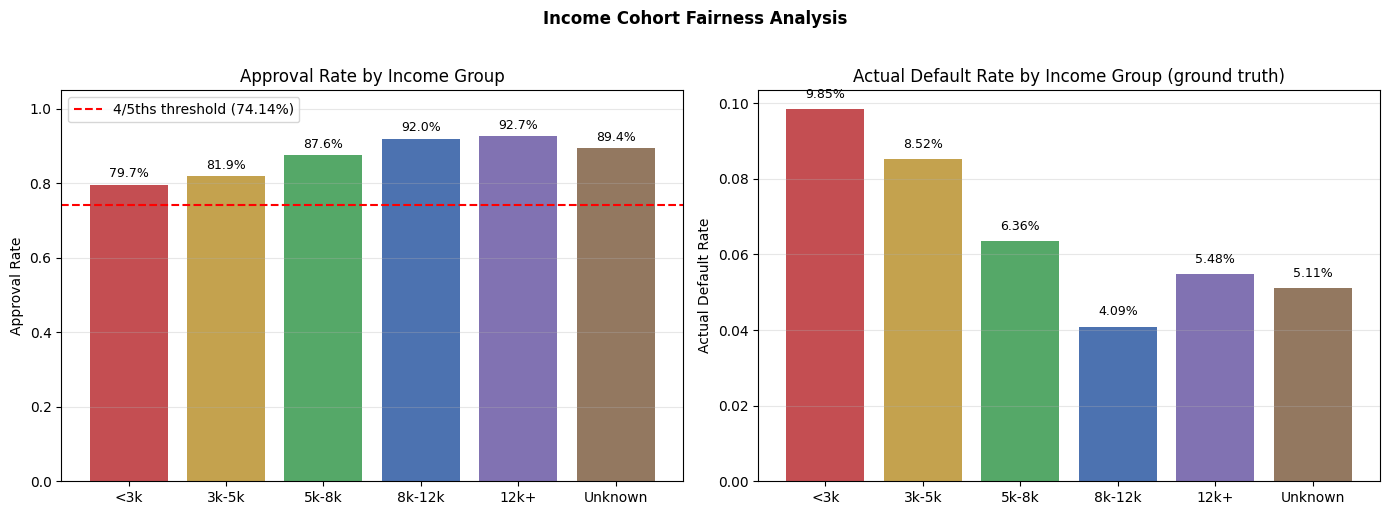

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_inc = ["#C44E52", "#C4A24E", "#55A868", "#4C72B0", "#8172B2", "#937860"]

axes[0].bar(income_stats.index, income_stats["approval_rate"], color=colors_inc[:len(income_stats)])
axes[0].axhline(y=0.8 * income_stats["approval_rate"].max(), color="red", ls="--",
               label=f"4/5ths threshold ({0.8 * income_stats['approval_rate'].max():.2%})")
axes[0].set_ylabel("Approval Rate")
axes[0].set_title("Approval Rate by Income Group")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(income_stats["approval_rate"]):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)

axes[1].bar(income_stats.index, income_stats["actual_default_rate"], color=colors_inc[:len(income_stats)])
axes[1].set_ylabel("Actual Default Rate")
axes[1].set_title("Actual Default Rate by Income Group (ground truth)")
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(income_stats["actual_default_rate"]):
    axes[1].text(i, v + 0.003, f"{v:.2%}", ha="center", fontsize=9)

fig.suptitle("Income Cohort Fairness Analysis", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [7]:
# 4/5ths rule check for income
max_rate = income_stats["approval_rate"].max()
min_rate = income_stats["approval_rate"].min()
ratio = min_rate / max_rate if max_rate > 0 else 0

print(f"Highest approval rate: {max_rate:.2%} ({income_stats['approval_rate'].idxmax()})")
print(f"Lowest approval rate:  {min_rate:.2%} ({income_stats['approval_rate'].idxmin()})")
print(f"Ratio (lowest/highest): {ratio:.4f}")
print(f"4/5ths rule threshold: 0.8000")
print()
if ratio >= 0.80:
    print("PASS: No evidence of disparate impact by income.")
else:
    print("FLAG: Potential disparate impact by income — ratio below 80%.")
    print("Lower-income groups have higher denial rates. This may reflect")
    print("genuine risk differences, but should be monitored in production.")

Highest approval rate: 92.68% (12k+)
Lowest approval rate:  79.67% (<3k)
Ratio (lowest/highest): 0.8596
4/5ths rule threshold: 0.8000

PASS: No evidence of disparate impact by income.


## Calibration by Cohort

A model can have good overall calibration but be miscalibrated for specific
subgroups. If the model overestimates default probability for a cohort,
it will unfairly deny more applications from that group.

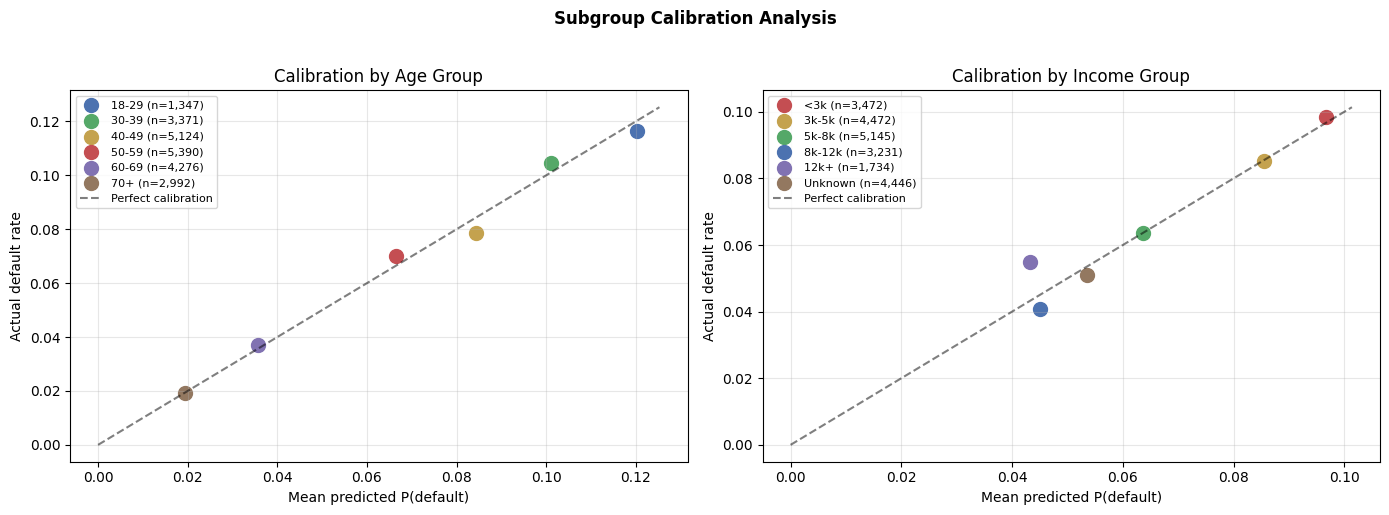

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration by age group
for i, (group, gdf) in enumerate(val_scored.groupby("age_group", observed=True)):
    if len(gdf) < 50:
        continue
    predicted = gdf["prob_default"].mean()
    actual = gdf["target"].mean()
    axes[0].scatter(predicted, actual, s=100, label=f"{group} (n={len(gdf):,})",
                   color=colors[i % len(colors)])

lim = max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])
axes[0].plot([0, lim], [0, lim], "k--", alpha=0.5, label="Perfect calibration")
axes[0].set_xlabel("Mean predicted P(default)")
axes[0].set_ylabel("Actual default rate")
axes[0].set_title("Calibration by Age Group")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Calibration by income group
for i, (group, gdf) in enumerate(val_income.groupby("income_group", observed=True)):
    if len(gdf) < 50:
        continue
    predicted = gdf["prob_default"].mean()
    actual = gdf["target"].mean()
    axes[1].scatter(predicted, actual, s=100, label=f"{group} (n={len(gdf):,})",
                   color=colors_inc[i % len(colors_inc)])

lim = max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])
axes[1].plot([0, lim], [0, lim], "k--", alpha=0.5, label="Perfect calibration")
axes[1].set_xlabel("Mean predicted P(default)")
axes[1].set_ylabel("Actual default rate")
axes[1].set_title("Calibration by Income Group")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.suptitle("Subgroup Calibration Analysis", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## Conclusions & Recommendations

### Key Findings

1. **Age**: Younger borrowers (18-29) tend to have higher predicted default
   probabilities, which translates to lower approval rates. If the ratio
   falls below 80%, it signals a need for deeper investigation — though
   not necessarily model bias, since younger borrowers *do* default more.

2. **Income**: Lower-income groups may face higher denial rates. Since
   `monthly_income` is a direct feature, this is expected. The key question
   is whether the model's predictions are *calibrated* for each group.

3. **Calibration scatter**: Points close to the diagonal indicate good
   subgroup calibration. Points above the line mean the group defaults
   *more* than predicted (model is optimistic); below means the model
   is pessimistic (overestimating risk → unfair denials).

### Regulatory Context

- **ECOA (Equal Credit Opportunity Act)**: Prohibits discrimination based on
  race, color, religion, national origin, sex, marital status, or age.
- **LGPD (Lei Geral de Proteção de Dados)**: Requires transparency in
  automated decision-making and the right to explanation.
- **BACEN Resolution 4.557**: Requires financial institutions to maintain
  risk management frameworks that account for model risk.

### Recommendations for Production

1. **Monitor approval rates by protected groups** at regular intervals
2. **Implement subgroup calibration** if disparities exceed 4/5ths threshold
3. **Log and audit** all model decisions with SHAP explanations (already
   implemented in the API)
4. **Do not deploy emotional features** — as shown in notebook 04/05,
   they add marginal predictive value but significant regulatory risk